In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
es_df = pd.read_csv("C:/Users/juana/Documents/TradingEnviroment/DataScienceProyect/datasets/sp500_df_data_daily.csv")
vix_df = pd.read_csv("C:/Users/juana/Documents/TradingEnviroment/DataScienceProyect/datasets/vix_2026_data_daily.csv")

vix_df = vix_df.rename(
    columns={
        "open": "vix_open",
        "high": "vix_high",
        "low": "vix_low",
        "close": "vix_close",
        "volume": "vix_volume",
        "avg_hl": "vix_avg_hl",
    }
)

# Concatenar ambos dataframes por fecha desde el inicio
df = es_df.merge(vix_df, on="date", how="inner")

df["date"] = pd.to_datetime(df["date"])

df = df.set_index("date").sort_index()

display(df.head())


,open,high,low,close,volume,pct_move,vix_open,vix_high,vix_low,vix_close,vix_volume,vix_avg_hl
date,,,,,,,,,,,,
2005-01-03,1211.920044,1217.800049,1200.319946,1202.079956,1510800000,1.442348,13.39,14.23,13.25,14.08,0,13.740
2005-01-04,1202.079956,1205.839966,1185.390015,1188.050049,1721000000,1.701214,14.01,14.45,13.93,13.98,0,14.190
2005-01-05,1188.050049,1192.729980,1183.719971,1183.739990,1738900000,0.758386,13.98,14.09,13.26,14.09,0,13.675
2005-01-06,1183.739990,1191.630005,1183.270020,1187.890015,1569100000,0.706235,14.09,14.09,13.33,13.58,0,13.710
2005-01-07,1187.890015,1192.199951,1182.160034,1186.189941,1477900000,0.845189,13.47,13.51,12.94,13.49,0,13.225


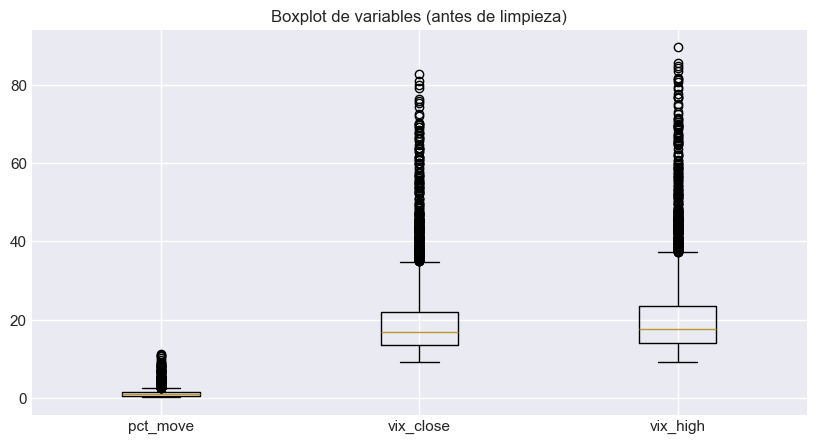

Filas originales: 5376 | Filas despues de limpiar vix_high: 5119


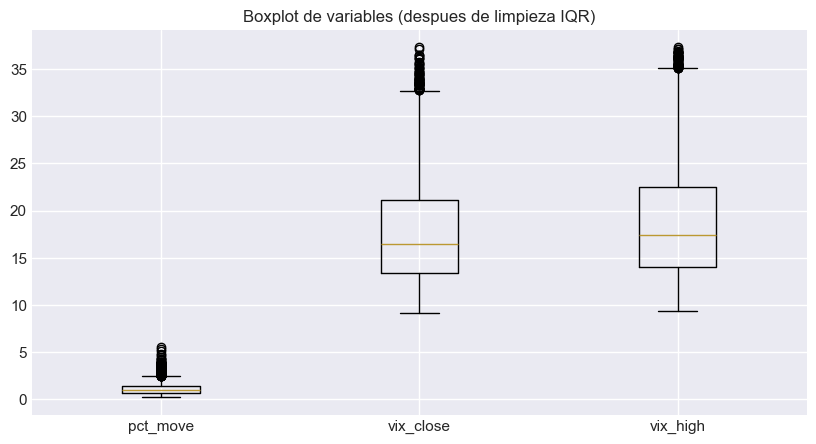

In [91]:
features = ["pct_move", "vix_close", "vix_high"]

plt.figure(figsize=(10, 5))
plt.boxplot([df[col] for col in features], labels=features)
plt.title("Boxplot de variables (antes de limpieza)")
plt.grid(True)
plt.show()

columna = "vix_high"

Q1 = df[columna].quantile(0.25)
Q3 = df[columna].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_limpio = df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]

print(f"Filas originales: {len(df)} | Filas despues de limpiar {columna}: {len(df_limpio)}")

plt.figure(figsize=(10, 5))
plt.boxplot([df_limpio[col] for col in features], labels=features)
plt.title("Boxplot de variables (despues de limpieza IQR)")
plt.grid(True)
plt.show()

In [92]:
df = df_limpio.copy()

# Eliminar columnas que no se usaran

df = df.drop(columns=["volume", "pct_move", "vix_volume"], errors="ignore")

# Transformaciones logaritmicas y features

# 1. Precios base logarítmicos
df["close_log"] = np.log(df["close"])
df["high_log"] = np.log(df["high"])
df["low_log"] = np.log(df["low"])

df["log_range"] = (df["high_log"] - df["low_log"])
df["target"] = df["log_range"].shift(-1)

# VIX de AYER
df["VIX_Vol_Diaria_lag1"] = (df["vix_close"] / (100 * np.sqrt(252)))
df["VIX_Rango_Log_lag1"] = (np.log(df["vix_high"]) - np.log(df["vix_low"]))
 



# Eliminar filas NaN generadas por los shifts
df = df.dropna()

display(df.tail())


,open,high,low,close,vix_open,vix_high,vix_low,vix_close,vix_avg_hl,close_log,high_log,low_log,log_range,target,VIX_Vol_Diaria_lag1,VIX_Rango_Log_lag1
date,,,,,,,,,,,,,,,,
2026-05-08,7362.970215,7401.500000,7362.970215,7398.930176,17.370001,17.530001,16.820000,17.190001,17.175000,8.909091,8.909438,8.904219,0.005219,0.006045,0.010829,0.041345
2026-05-11,7385.310059,7428.970215,7384.200195,7412.839844,18.209999,18.469999,17.900000,18.379999,18.184999,8.910969,8.913143,8.907098,0.006045,0.009632,0.011578,0.031347
2026-05-12,7390.629883,7409.569824,7338.540039,7400.959961,18.770000,19.100000,17.920000,17.990000,18.510000,8.909365,8.910528,8.900895,0.009632,0.011447,0.011333,0.063771
2026-05-13,7409.120117,7460.040039,7375.129883,7444.250000,17.980000,18.400000,17.760000,17.870001,18.080000,8.915197,8.917316,8.905869,0.011447,0.008379,0.011257,0.035402
2026-05-14,7454.399902,7517.120117,7454.399902,7501.240234,17.860001,18.080000,17.200001,17.260000,17.640000,8.922824,8.924938,8.916560,0.008379,0.007723,0.010873,0.049897


In [93]:

df.dropna(inplace=True)
# Eliminar precios en bruto y columnas no necesarias

display(df.head())

,open,high,low,close,vix_open,vix_high,vix_low,vix_close,vix_avg_hl,close_log,high_log,low_log,log_range,target,VIX_Vol_Diaria_lag1,VIX_Rango_Log_lag1
date,,,,,,,,,,,,,,,,
2005-01-03,1211.920044,1217.800049,1200.319946,1202.079956,13.39,14.23,13.25,14.08,13.740,7.091809,7.104801,7.090343,0.014458,0.017105,0.008870,0.071355
2005-01-04,1202.079956,1205.839966,1185.390015,1188.050049,14.01,14.45,13.93,13.98,14.190,7.080069,7.094932,7.077827,0.017105,0.007583,0.008807,0.036650
2005-01-05,1188.050049,1192.729980,1183.719971,1183.739990,13.98,14.09,13.26,14.09,13.675,7.076434,7.084000,7.076417,0.007583,0.007040,0.008876,0.060713
2005-01-06,1183.739990,1191.630005,1183.270020,1187.890015,14.09,14.09,13.33,13.58,13.710,7.079934,7.083077,7.076037,0.007040,0.008457,0.008555,0.055448
2005-01-07,1187.890015,1192.199951,1182.160034,1186.189941,13.47,13.51,12.94,13.49,13.225,7.078502,7.083556,7.075099,0.008457,0.008388,0.008498,0.043107


In [94]:
model_df = df.loc[:"2020-12-31"].copy()
model_df = model_df.drop(
    columns=[
        
        "vix_open",
        "vix_high",
        "vix_low",
        "vix_close",
        "vix_avg_hl",
        "open",
        "high",
        "low",
        "close",
        
        
    ],
    errors="ignore",
)
display(model_df.tail())


,close_log,high_log,low_log,log_range,target,VIX_Vol_Diaria_lag1,VIX_Rango_Log_lag1
date,,,,,,,
2020-12-24,8.216915,8.217120,8.213197,0.003923,0.004684,0.013563,0.065152
2020-12-28,8.225600,8.226977,8.222293,0.004684,0.008773,0.013670,0.044842
2020-12-29,8.223370,8.231142,8.222368,0.008773,0.003858,0.014539,0.122272
2020-12-30,8.224710,8.228078,8.224220,0.003858,0.008901,0.014344,0.032487
2020-12-31,8.231128,8.232227,8.223327,0.008901,0.028869,0.014331,0.090419


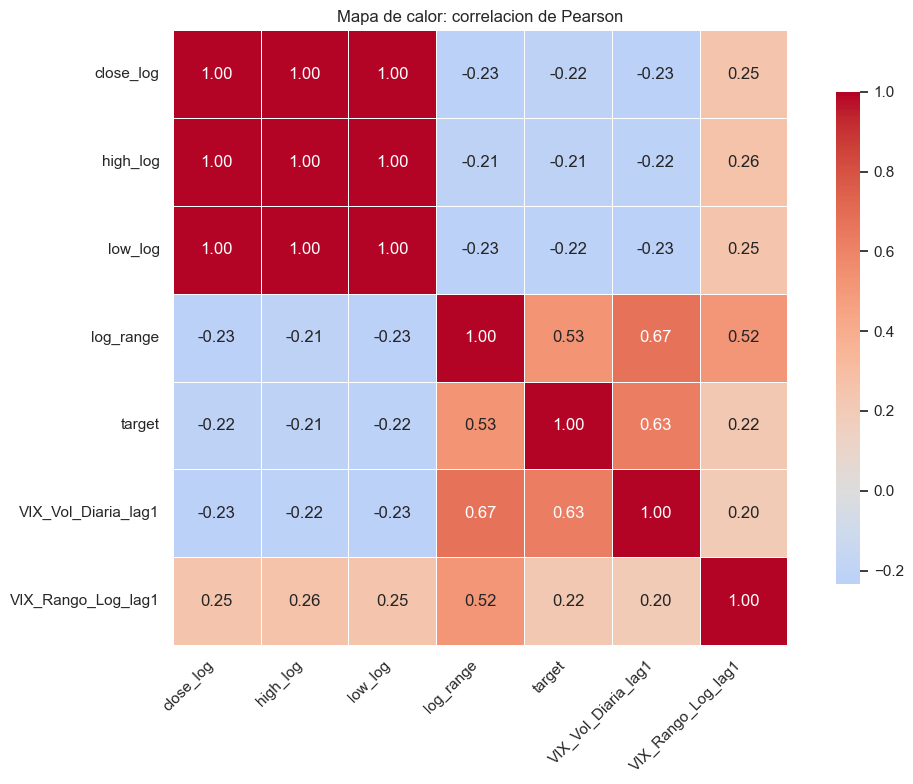

In [95]:
sns.set_theme(style="white")

numeric_df = model_df.select_dtypes(include=[np.number])

corr = numeric_df.corr(method="pearson")

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Mapa de calor: correlacion de Pearson")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


PIPELINE DE MACHINE LEARNING PARA SERIES DE TIEMPO
Inicio: 2026-05-19 18:54:01


[1] CARGANDO DATOS...
--------------------------------------------------------------------------------
✓ Datos cargados exitosamente
  - Forma del dataset: (3782, 7)
  - Columnas: ['close_log', 'high_log', 'low_log', 'log_range', 'target', 'VIX_Vol_Diaria_lag1', 'VIX_Rango_Log_lag1']

  Primeras filas:
            close_log  high_log   low_log  log_range    target  \
date                                                             
2005-01-03   7.091809  7.104801  7.090343   0.014458  0.017105   
2005-01-04   7.080069  7.094932  7.077827   0.017105  0.007583   
2005-01-05   7.076434  7.084000  7.076417   0.007583  0.007040   
2005-01-06   7.079934  7.083077  7.076037   0.007040  0.008457   
2005-01-07   7.078502  7.083556  7.075099   0.008457  0.008388   

            VIX_Vol_Diaria_lag1  VIX_Rango_Log_lag1  
date                                                 
2005-01-03             0.008870            0

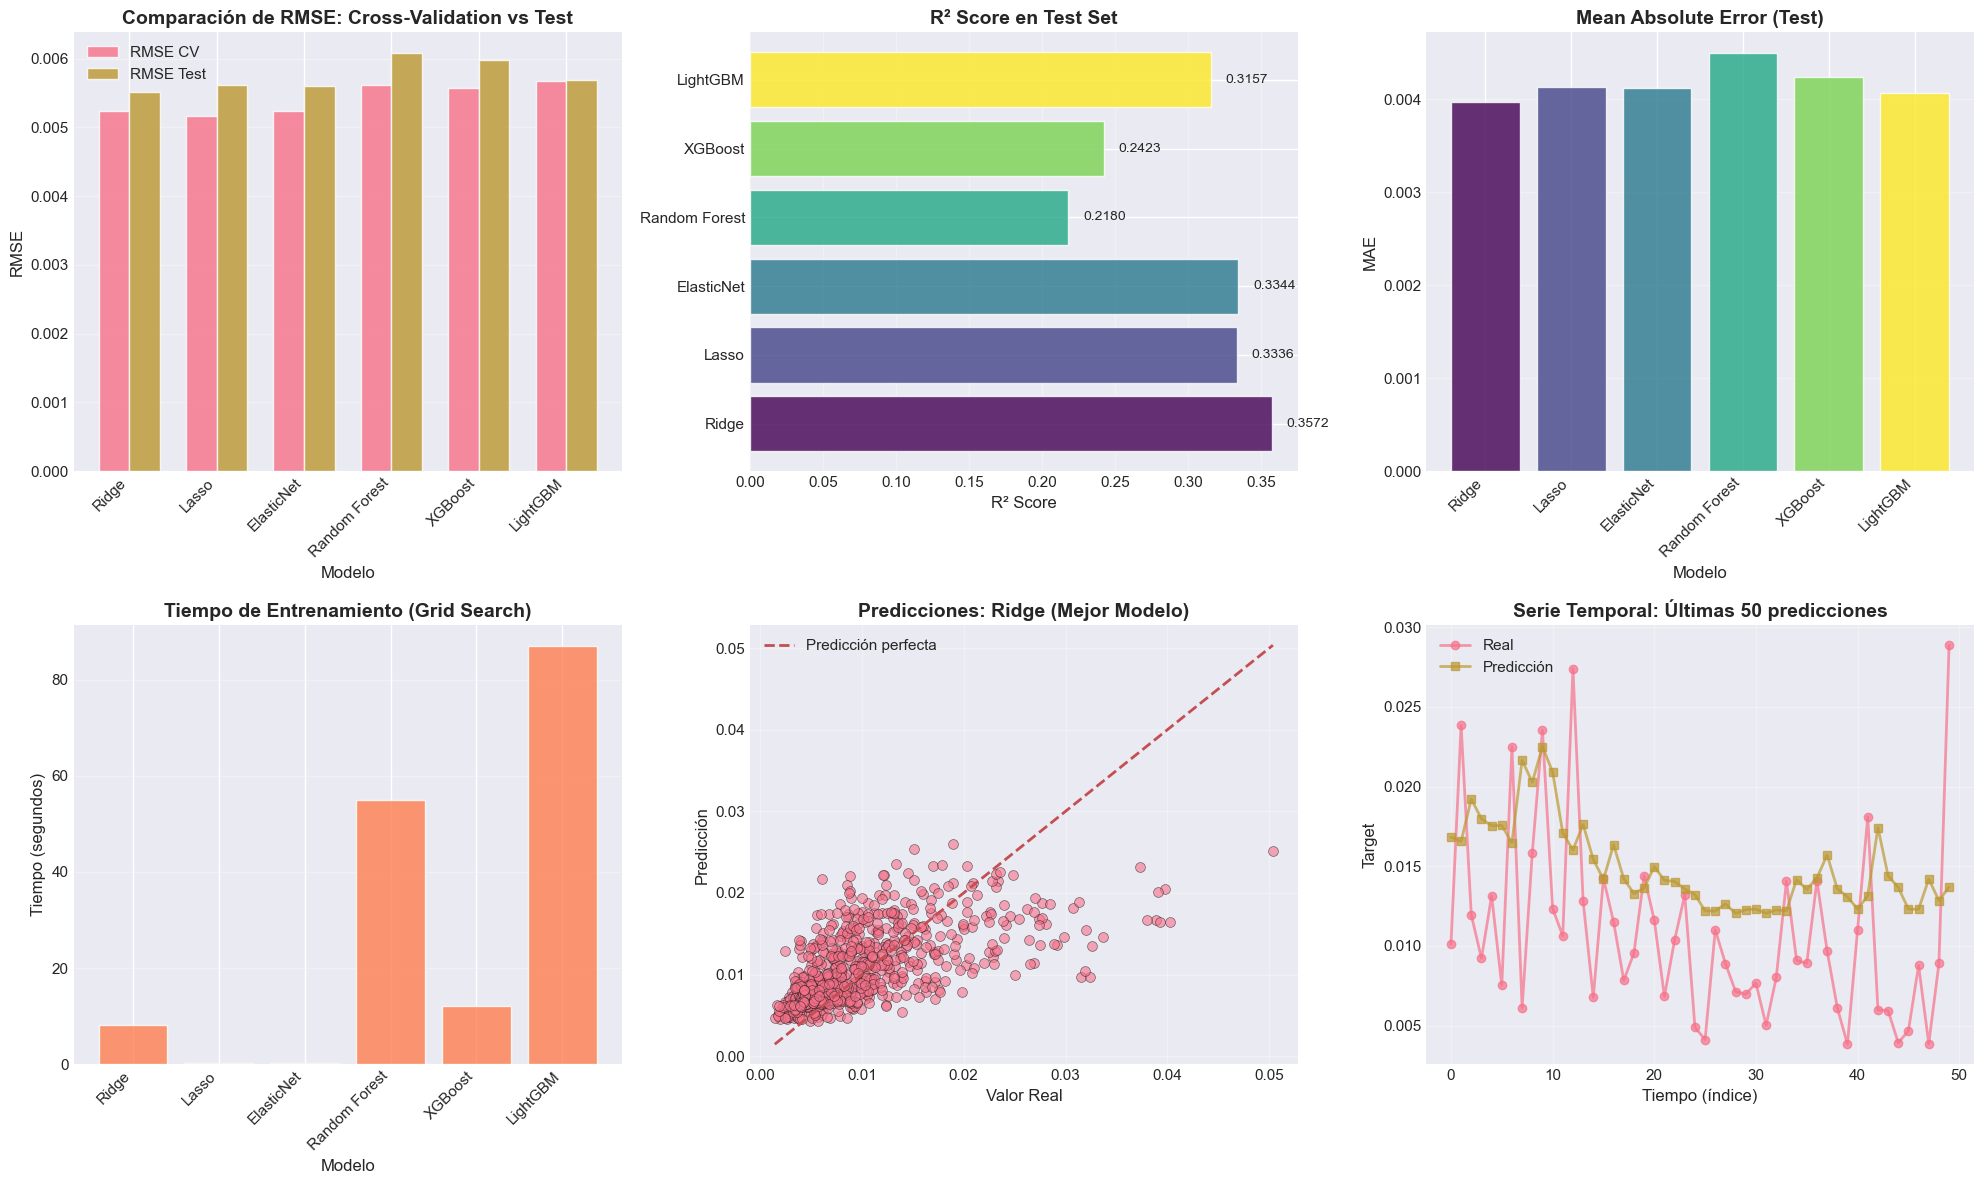


[7] TABLA DE RESULTADOS FINALES
       Modelo  RMSE_CV  RMSE_Test  MAE_Test  R2_Test  Tiempo (s)
        Ridge 0.005232   0.005511  0.003974 0.357198    8.094915
   ElasticNet 0.005246   0.005608  0.004124 0.334386    0.195261
        Lasso 0.005168   0.005611  0.004135 0.333612    0.193464
     LightGBM 0.005670   0.005686  0.004070 0.315654   86.981483
      XGBoost 0.005578   0.005983  0.004240 0.242307   12.102468
Random Forest 0.005615   0.006079  0.004496 0.217988   55.032646

✓ Resultados guardados: 'model_comparison_results.csv'

🏆 MEJOR MODELO: Ridge
   RMSE en Test: 0.005511

[8] ANÁLISIS DE FEATURE IMPORTANCE...
--------------------------------------------------------------------------------

Random Forest - Top 5 Features:
            Feature  Importance
VIX_Vol_Diaria_lag1    0.836679
          log_range    0.041964
          close_log    0.041302
 VIX_Rango_Log_lag1    0.035382
            low_log    0.024784

XGBoost - Top 5 Features:
            Feature  Importance
VIX

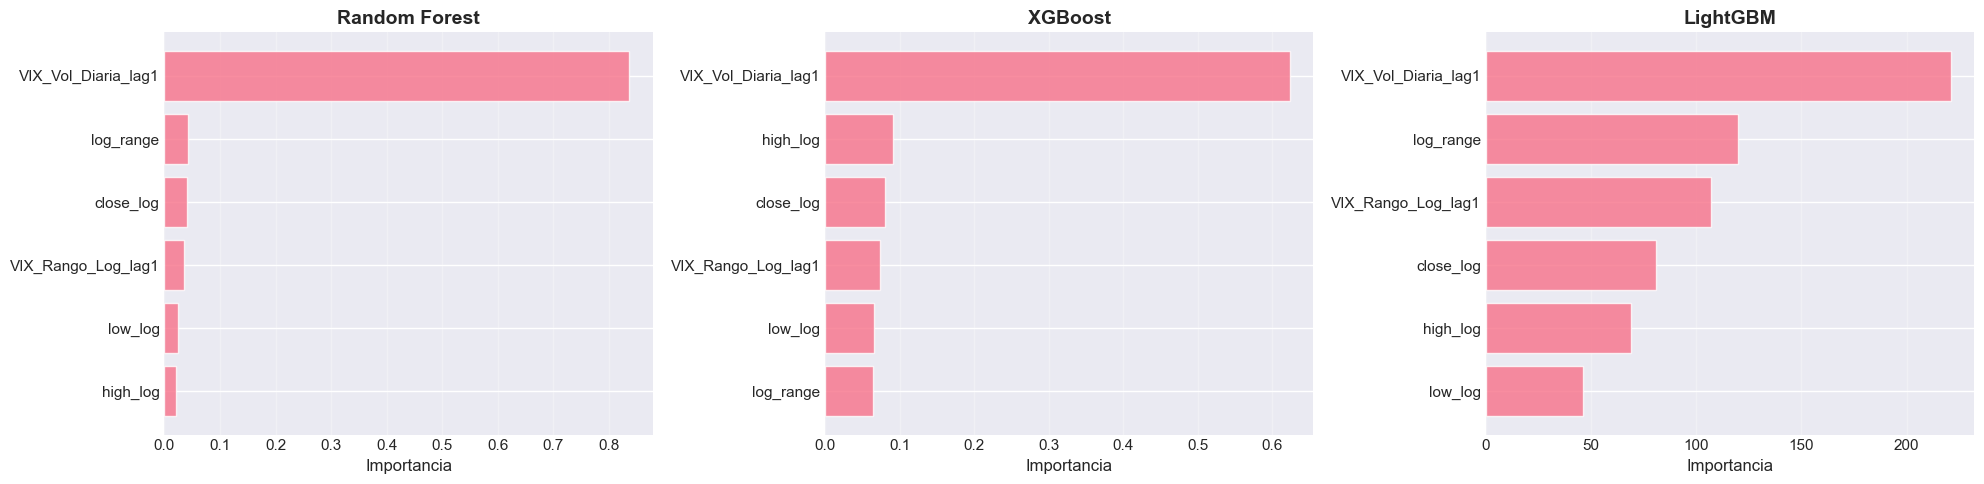


[9] GUARDANDO MEJOR MODELO...
--------------------------------------------------------------------------------
✓ Modelo guardado: 'best_model_Ridge.pkl'
✓ Scaler guardado: 'scaler.pkl'

Para cargar el modelo:
  modelo = joblib.load('best_model_Ridge.pkl')
  scaler = joblib.load('scaler.pkl')

✓ PIPELINE COMPLETADO EXITOSAMENTE
Fin: 2026-05-19 18:56:47


In [ ]:
"""
Pipeline Completo de Machine Learning para Series de Tiempo
Predicción de 'target' del SP500 con 6 modelos y Grid Search
Autor: Pipeline automatizado
Fecha: 2026-05-19
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Importar modelos
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Importar herramientas de preprocesamiento y validación
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# ============================================================================
# 1. CONFIGURACIÓN INICIAL
# ============================================================================

# Configurar visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("="*80)
print("PIPELINE DE MACHINE LEARNING PARA SERIES DE TIEMPO")
print("="*80)
print(f"Inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")


# ============================================================================
# 2. CARGA Y EXPLORACIÓN DE DATOS
# ============================================================================

def cargar_y_explorar_datos(data_df):
    """
    Carga y explora el dataset de series de tiempo
    """
    print("\n[1] CARGANDO DATOS...")
    print("-" * 80)
    
    model_df = data_df.copy()
    
    print(f"✓ Datos cargados exitosamente")
    print(f"  - Forma del dataset: {model_df.shape}")
    print(f"  - Columnas: {list(model_df.columns)}")
    
    # Información básica
    print(f"\n  Primeras filas:")
    print(model_df.head())
    
    print(f"\n  Información del dataset:")
    print(model_df.info())
    
    print(f"\n  Estadísticas descriptivas:")
    print(model_df.describe())
    
    # Verificar valores nulos
    nulls = model_df.isnull().sum()
    if nulls.sum() > 0:
        print(f"\n  ⚠️  Valores nulos detectados:")
        print(nulls[nulls > 0])
    else:
        print(f"\n  ✓ No hay valores nulos")
    
    return model_df


# ============================================================================
# 3. PREPARACIÓN DE DATOS
# ============================================================================

def preparar_datos(model_df):
    """
    Prepara los datos para entrenamiento:
    - Ordena por fecha
    - Separa features y target
    - Escala las features
    - Split temporal
    """
    print("\n[2] PREPARANDO DATOS...")
    print("-" * 80)
    
    # Separar features y target
    X = model_df.drop(['target'], axis=1)
    y = model_df['target']
    
    print(f"✓ Features (X): {X.shape[1]} variables")
    print(f"  Columnas: {list(X.columns)}")
    print(f"✓ Target (y): {y.shape[0]} observaciones")
    print(f"  Estadísticas del target:")
    print(f"    - Media: {y.mean():.6f}")
    print(f"    - Desv. Std: {y.std():.6f}")
    print(f"    - Min: {y.min():.6f}")
    print(f"    - Max: {y.max():.6f}")
    
    # Escalar features (importante para SVM, Ridge, Lasso)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
    print(f"✓ Features normalizadas con StandardScaler")
    
    # Split temporal (80% train, 20% test)
    split_idx = int(len(X_scaled) * 0.8)
    
    X_train = X_scaled[:split_idx]
    X_test = X_scaled[split_idx:]
    y_train = y[:split_idx]
    y_test = y[split_idx:]
    
    print(f"\n✓ Split temporal realizado:")
    print(f"  - Train: {X_train.shape[0]} muestras ({split_idx/len(X_scaled)*100:.1f}%)")
    print(f"  - Test: {X_test.shape[0]} muestras ({(len(X_scaled)-split_idx)/len(X_scaled)*100:.1f}%)")
    
    return X_train, X_test, y_train, y_test, scaler, X.columns


# ============================================================================
# 4. DEFINICIÓN DE MODELOS Y GRID SEARCH
# ============================================================================

def definir_modelos_y_grids():
    """
    Define 6 modelos y sus hiperparámetros para Grid Search
    """
    print("\n[3] DEFINIENDO MODELOS Y GRIDS DE HIPERPARÁMETROS...")
    print("-" * 80)
    
    modelos = {
        'Ridge': {
            'model': Ridge(random_state=RANDOM_STATE),
            'params': {
                'alpha': [0.001, 0.01, 0.1, 1, 10, 100],
                'fit_intercept': [True, False],
                'solver': ['auto', 'svd', 'saga']
            }
        },
        
        'Lasso': {
            'model': Lasso(random_state=RANDOM_STATE, max_iter=10000),
            'params': {
                'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
                'fit_intercept': [True, False],
                'selection': ['cyclic', 'random']
            }
        },
        
        'ElasticNet': {
            'model': ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
            'params': {
                'alpha': [0.001, 0.01, 0.1, 1],
                'l1_ratio': [0.2, 0.5, 0.8],
                'fit_intercept': [True, False]
            }
        },
        
        'Random Forest': {
            'model': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
            'params': {
                'n_estimators': [50, 100, 200],
                'max_depth': [5, 10, 15, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            }
        },
        
        'XGBoost': {
            'model': XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5, 7],
                'subsample': [0.8, 1.0],
                'colsample_bytree': [0.8, 1.0]
            }
        },
        
        'LightGBM': {
            'model': LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
            'params': {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5, 7, -1],
                'num_leaves': [15, 31, 63],
                'subsample': [0.8, 1.0]
            }
        }
    }
    
    print(f"✓ {len(modelos)} modelos definidos:")
    for nombre, config in modelos.items():
        n_combinaciones = np.prod([len(v) for v in config['params'].values()])
        print(f"  - {nombre}: {n_combinaciones} combinaciones de hiperparámetros")
    
    return modelos


# ============================================================================
# 5. ENTRENAMIENTO CON GRID SEARCH
# ============================================================================

def entrenar_modelos(X_train, y_train, modelos, n_splits=5):
    """
    Entrena todos los modelos usando Grid Search con TimeSeriesSplit
    """
    print(f"\n[4] ENTRENANDO MODELOS CON GRID SEARCH (Cross-Validation con {n_splits} splits)...")
    print("-" * 80)
    
    # Configurar TimeSeriesSplit para validación cruzada temporal
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    resultados = {}
    mejores_modelos = {}
    
    for nombre, config in modelos.items():
        print(f"\n🔄 Entrenando {nombre}...")
        inicio = datetime.now()
        
        # Grid Search
        grid_search = GridSearchCV(
            estimator=config['model'],
            param_grid=config['params'],
            cv=tscv,
            scoring='neg_mean_squared_error',  # RMSE
            n_jobs=-1,
            verbose=0,
            return_train_score=True
        )
        
        # Entrenar
        grid_search.fit(X_train, y_train)
        
        tiempo_transcurrido = (datetime.now() - inicio).total_seconds()
        
        # Guardar resultados
        mejor_rmse = np.sqrt(-grid_search.best_score_)
        resultados[nombre] = {
            'best_params': grid_search.best_params_,
            'best_rmse_cv': mejor_rmse,
            'tiempo_segundos': tiempo_transcurrido,
            'cv_results': grid_search.cv_results_
        }
        mejores_modelos[nombre] = grid_search.best_estimator_
        
        print(f"✓ {nombre} completado en {tiempo_transcurrido:.2f}s")
        print(f"  - Mejor RMSE (CV): {mejor_rmse:.6f}")
        print(f"  - Mejores hiperparámetros:")
        for param, value in grid_search.best_params_.items():
            print(f"    • {param}: {value}")
    
    return mejores_modelos, resultados


# ============================================================================
# 6. EVALUACIÓN EN TEST SET
# ============================================================================

def evaluar_modelos(mejores_modelos, X_train, X_test, y_train, y_test):
    """
    Evalúa todos los modelos en el conjunto de test
    """
    print("\n[5] EVALUANDO MODELOS EN TEST SET...")
    print("-" * 80)
    
    metricas_test = {}
    predicciones = {}
    
    for nombre, modelo in mejores_modelos.items():
        # Predicciones
        y_pred_train = modelo.predict(X_train)
        y_pred_test = modelo.predict(X_test)
        
        # Calcular métricas en train
        rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
        mae_train = mean_absolute_error(y_train, y_pred_train)
        r2_train = r2_score(y_train, y_pred_train)
        
        # Calcular métricas en test
        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        mae_test = mean_absolute_error(y_test, y_pred_test)
        r2_test = r2_score(y_test, y_pred_test)
        
        metricas_test[nombre] = {
            'RMSE_train': rmse_train,
            'MAE_train': mae_train,
            'R2_train': r2_train,
            'RMSE_test': rmse_test,
            'MAE_test': mae_test,
            'R2_test': r2_test
        }
        
        predicciones[nombre] = {
            'y_pred_train': y_pred_train,
            'y_pred_test': y_pred_test
        }
        
        print(f"\n{nombre}:")
        print(f"  Train - RMSE: {rmse_train:.6f} | MAE: {mae_train:.6f} | R²: {r2_train:.4f}")
        print(f"  Test  - RMSE: {rmse_test:.6f} | MAE: {mae_test:.6f} | R²: {r2_test:.4f}")
    
    return metricas_test, predicciones


# ============================================================================
# 7. VISUALIZACIONES Y COMPARACIÓN
# ============================================================================

def visualizar_resultados(metricas_test, resultados, predicciones, y_train, y_test):
    """
    Crea visualizaciones comparativas de los modelos
    """
    print("\n[6] GENERANDO VISUALIZACIONES...")
    print("-" * 80)
    
    # Crear figura con múltiples subplots
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Comparación de RMSE (CV vs Test)
    ax1 = plt.subplot(2, 3, 1)
    nombres = list(metricas_test.keys())
    rmse_cv = [resultados[n]['best_rmse_cv'] for n in nombres]
    rmse_test = [metricas_test[n]['RMSE_test'] for n in nombres]
    
    x = np.arange(len(nombres))
    width = 0.35
    
    ax1.bar(x - width/2, rmse_cv, width, label='RMSE CV', alpha=0.8)
    ax1.bar(x + width/2, rmse_test, width, label='RMSE Test', alpha=0.8)
    ax1.set_xlabel('Modelo', fontsize=12)
    ax1.set_ylabel('RMSE', fontsize=12)
    ax1.set_title('Comparación de RMSE: Cross-Validation vs Test', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(nombres, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. R² Score Comparison
    ax2 = plt.subplot(2, 3, 2)
    r2_scores = [metricas_test[n]['R2_test'] for n in nombres]
    colors = plt.cm.viridis(np.linspace(0, 1, len(nombres)))
    
    bars = ax2.barh(nombres, r2_scores, color=colors, alpha=0.8)
    ax2.set_xlabel('R² Score', fontsize=12)
    ax2.set_title('R² Score en Test Set', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)
    
    # Añadir valores en las barras
    for i, (bar, r2) in enumerate(zip(bars, r2_scores)):
        ax2.text(r2 + 0.01, i, f'{r2:.4f}', va='center', fontsize=10)
    
    # 3. MAE Comparison
    ax3 = plt.subplot(2, 3, 3)
    mae_test = [metricas_test[n]['MAE_test'] for n in nombres]
    
    ax3.bar(nombres, mae_test, color=colors, alpha=0.8)
    ax3.set_xlabel('Modelo', fontsize=12)
    ax3.set_ylabel('MAE', fontsize=12)
    ax3.set_title('Mean Absolute Error (Test)', fontsize=14, fontweight='bold')
    ax3.set_xticklabels(nombres, rotation=45, ha='right')
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Tiempo de entrenamiento
    ax4 = plt.subplot(2, 3, 4)
    tiempos = [resultados[n]['tiempo_segundos'] for n in nombres]
    
    ax4.bar(nombres, tiempos, color='coral', alpha=0.8)
    ax4.set_xlabel('Modelo', fontsize=12)
    ax4.set_ylabel('Tiempo (segundos)', fontsize=12)
    ax4.set_title('Tiempo de Entrenamiento (Grid Search)', fontsize=14, fontweight='bold')
    ax4.set_xticklabels(nombres, rotation=45, ha='right')
    ax4.grid(axis='y', alpha=0.3)
    
    # 5. Predicciones del mejor modelo (en test)
    ax5 = plt.subplot(2, 3, 5)
    mejor_modelo_nombre = min(metricas_test.items(), key=lambda x: x[1]['RMSE_test'])[0]
    y_pred_best = predicciones[mejor_modelo_nombre]['y_pred_test']
    
    ax5.scatter(y_test, y_pred_best, alpha=0.6, s=50, edgecolors='k', linewidths=0.5)
    
    # Línea diagonal perfecta
    min_val = min(y_test.min(), y_pred_best.min())
    max_val = max(y_test.max(), y_pred_best.max())
    ax5.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción perfecta')
    
    ax5.set_xlabel('Valor Real', fontsize=12)
    ax5.set_ylabel('Predicción', fontsize=12)
    ax5.set_title(f'Predicciones: {mejor_modelo_nombre} (Mejor Modelo)', fontsize=14, fontweight='bold')
    ax5.legend()
    ax5.grid(alpha=0.3)
    
    # 6. Series temporales (últimas predicciones)
    ax6 = plt.subplot(2, 3, 6)
    n_show = min(50, len(y_test))  # Mostrar últimas 50 observaciones
    
    ax6.plot(range(n_show), y_test.values[-n_show:], 'o-', label='Real', alpha=0.7, linewidth=2)
    ax6.plot(range(n_show), y_pred_best[-n_show:], 's-', label='Predicción', alpha=0.7, linewidth=2)
    ax6.set_xlabel('Tiempo (índice)', fontsize=12)
    ax6.set_ylabel('Target', fontsize=12)
    ax6.set_title(f'Serie Temporal: Últimas {n_show} predicciones', fontsize=14, fontweight='bold')
    ax6.legend()
    ax6.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('model_comparison_results.png', dpi=300, bbox_inches='tight')
    print("✓ Gráfico guardado: 'model_comparison_results.png'")
    plt.show()
    
    return mejor_modelo_nombre


# ============================================================================
# 8. TABLA DE RESULTADOS
# ============================================================================

def crear_tabla_resultados(metricas_test, resultados):
    """
    Crea tabla comparativa de todos los modelos
    """
    print("\n[7] TABLA DE RESULTADOS FINALES")
    print("=" * 80)
    
    # Crear DataFrame con resultados
    data = []
    for nombre in metricas_test.keys():
        data.append({
            'Modelo': nombre,
            'RMSE_CV': resultados[nombre]['best_rmse_cv'],
            'RMSE_Test': metricas_test[nombre]['RMSE_test'],
            'MAE_Test': metricas_test[nombre]['MAE_test'],
            'R2_Test': metricas_test[nombre]['R2_test'],
            'Tiempo (s)': resultados[nombre]['tiempo_segundos']
        })
    
    df_resultados = pd.DataFrame(data)
    df_resultados = df_resultados.sort_values('RMSE_Test')
    
    print(df_resultados.to_string(index=False))
    
    # Guardar resultados
    df_resultados.to_csv('model_comparison_results.csv', index=False)
    print("\n✓ Resultados guardados: 'model_comparison_results.csv'")
    
    # Encontrar el mejor modelo
    mejor_modelo = df_resultados.iloc[0]['Modelo']
    mejor_rmse = df_resultados.iloc[0]['RMSE_Test']
    
    print("\n" + "="*80)
    print(f"🏆 MEJOR MODELO: {mejor_modelo}")
    print(f"   RMSE en Test: {mejor_rmse:.6f}")
    print("="*80)
    
    return df_resultados


# ============================================================================
# 9. FEATURE IMPORTANCE (si el modelo lo soporta)
# ============================================================================

def analizar_feature_importance(mejores_modelos, feature_names):
    """
    Analiza la importancia de features para modelos basados en árboles
    """
    print("\n[8] ANÁLISIS DE FEATURE IMPORTANCE...")
    print("-" * 80)
    
    modelos_con_importance = ['Random Forest', 'XGBoost', 'LightGBM']
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    for idx, nombre in enumerate(modelos_con_importance):
        if nombre in mejores_modelos:
            modelo = mejores_modelos[nombre]
            
            # Obtener importancias
            importances = modelo.feature_importances_
            indices = np.argsort(importances)[::-1]
            
            # Crear DataFrame
            df_importance = pd.DataFrame({
                'Feature': feature_names[indices],
                'Importance': importances[indices]
            })
            
            print(f"\n{nombre} - Top 5 Features:")
            print(df_importance.head(5).to_string(index=False))
            
            # Visualizar
            ax = axes[idx]
            ax.barh(df_importance['Feature'], df_importance['Importance'], alpha=0.8)
            ax.set_xlabel('Importancia', fontsize=12)
            ax.set_title(f'{nombre}', fontsize=14, fontweight='bold')
            ax.invert_yaxis()
            ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    print("\n✓ Gráfico guardado: 'feature_importance.png'")
    plt.show()


# ============================================================================
# 10. GUARDAR EL MEJOR MODELO
# ============================================================================

def guardar_mejor_modelo(mejores_modelos, metricas_test, scaler):
    """
    Guarda el mejor modelo y el scaler
    """
    print("\n[9] GUARDANDO MEJOR MODELO...")
    print("-" * 80)
    
    # Encontrar mejor modelo
    mejor_modelo_nombre = min(metricas_test.items(), key=lambda x: x[1]['RMSE_test'])[0]
    mejor_modelo = mejores_modelos[mejor_modelo_nombre]
    
    # Guardar modelo
    joblib.dump(mejor_modelo, f'best_model_{mejor_modelo_nombre.replace(" ", "_")}.pkl')
    print(f"✓ Modelo guardado: 'best_model_{mejor_modelo_nombre.replace(' ', '_')}.pkl'")
    
    # Guardar scaler
    joblib.dump(scaler, 'scaler.pkl')
    print(f"✓ Scaler guardado: 'scaler.pkl'")
    
    print(f"\nPara cargar el modelo:")
    print(f"  modelo = joblib.load('best_model_{mejor_modelo_nombre.replace(' ', '_')}.pkl')")
    print(f"  scaler = joblib.load('scaler.pkl')")


# ============================================================================
# FUNCIÓN PRINCIPAL
# ============================================================================

def main(data_df):
    """
    Ejecuta el pipeline completo
    """
    try:
        # 1. Cargar datos
        model_df = cargar_y_explorar_datos(data_df)
        
        # 2. Preparar datos
        X_train, X_test, y_train, y_test, scaler, feature_names = preparar_datos(model_df)
        
        # 3. Definir modelos
        modelos = definir_modelos_y_grids()
        
        # 4. Entrenar con Grid Search
        mejores_modelos, resultados = entrenar_modelos(X_train, y_train, modelos, n_splits=5)
        
        # 5. Evaluar en test
        metricas_test, predicciones = evaluar_modelos(mejores_modelos, X_train, X_test, y_train, y_test)
        
        # 6. Visualizar
        mejor_modelo_nombre = visualizar_resultados(metricas_test, resultados, predicciones, y_train, y_test)
        
        # 7. Tabla de resultados
        df_resultados = crear_tabla_resultados(metricas_test, resultados)
        
        # 8. Feature importance
        analizar_feature_importance(mejores_modelos, feature_names)
        
        # 9. Guardar mejor modelo
        guardar_mejor_modelo(mejores_modelos, metricas_test, scaler)
        
        print("\n" + "="*80)
        print("✓ PIPELINE COMPLETADO EXITOSAMENTE")
        print("="*80)
        print(f"Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        
        return mejores_modelos, metricas_test, df_resultados
        
    except Exception as e:
        print(f"\n❌ ERROR: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None, None


# ============================================================================
# EJECUTAR EL PIPELINE
# ============================================================================

mejores_modelos, metricas_test, df_resultados = main(model_df)

In [96]:
import math 
e = math.e
i = 0.005511
print(e**i)

1.0055262134948506


In [100]:
df_validation = df.loc["2021-01-01":"2026-05-13"].copy()
df_validation = df_validation.drop(
    columns=[
        
        "vix_open",
        "vix_high",
        "vix_low",
        "vix_close",
        "vix_avg_hl",
        "open",
        "high",
        "low",
        "close",
        
        
        
    ],
    errors="ignore",
)
display(df_validation.head())

,close_log,high_log,low_log,log_range,target,VIX_Vol_Diaria_lag1,VIX_Rango_Log_lag1
date,,,,,,,
2021-01-04,8.216264,8.234828,8.205959,0.028869,0.011506,0.016990,0.257648
2021-01-05,8.223321,8.226261,8.214755,0.011506,0.020753,0.015963,0.142563
2021-01-06,8.229015,8.238283,8.217530,0.020753,0.012365,0.015793,0.189896
2021-01-07,8.243753,8.245791,8.233426,0.012365,0.011324,0.014092,0.071955
2021-01-08,8.249230,8.249755,8.238431,0.011324,0.007583,0.013582,0.085844


In [101]:
import joblib
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np


def walk_forward_retrain(base_model, train_df, oos_df, retrain_months=6):
    train_df = train_df.copy()
    oos_df = oos_df.copy()

    if not isinstance(train_df.index, pd.DatetimeIndex):
        train_df.index = pd.to_datetime(train_df.index)
    if not isinstance(oos_df.index, pd.DatetimeIndex):
        oos_df.index = pd.to_datetime(oos_df.index)

    train_df = train_df.sort_index()
    oos_df = oos_df.sort_index()

    feature_cols = [c for c in train_df.columns if c != "target"]
    missing = set(feature_cols) - set(oos_df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en df_validation: {sorted(missing)}")

    full_df = pd.concat([train_df, oos_df]).sort_index()
    oos_start = oos_df.index.min()
    oos_end = oos_df.index.max()

    retrain_dates = [oos_start]
    while retrain_dates[-1] < oos_end:
        retrain_dates.append(retrain_dates[-1] + pd.DateOffset(months=retrain_months))

    preds = []
    blocks = []

    for i, start in enumerate(retrain_dates):
        next_start = retrain_dates[i + 1] if i + 1 < len(retrain_dates) else (oos_end + pd.Timedelta(days=1))
        test_block = oos_df[(oos_df.index >= start) & (oos_df.index < next_start)]
        if test_block.empty:
            continue

        train_block = full_df[full_df.index < start]
        if train_block.empty:
            raise ValueError(f"No hay data de entrenamiento antes de {start}")

        X_train = train_block[feature_cols]
        y_train = train_block["target"]
        X_test = test_block[feature_cols]
        y_test = test_block["target"]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = clone(base_model)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        block_df = pd.DataFrame({"y_true": y_test.values, "y_pred": y_pred}, index=y_test.index)
        block_df["train_end"] = train_block.index.max()
        block_df["test_start"] = test_block.index.min()
        block_df["test_end"] = test_block.index.max()
        preds.append(block_df)

        blocks.append({
            "test_start": test_block.index.min(),
            "test_end": test_block.index.max(),
            "n_test": len(test_block),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "mae": mean_absolute_error(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
        })

    preds_df = pd.concat(preds).sort_index()
    blocks_df = pd.DataFrame(blocks)
    return preds_df, blocks_df


base_model = joblib.load("best_model_Ridge.pkl")

wf_preds, wf_blocks = walk_forward_retrain(
    base_model=base_model,
    train_df=model_df,
    oos_df=df_validation,
    retrain_months=6,
)

rmse_wf = np.sqrt(mean_squared_error(wf_preds["y_true"], wf_preds["y_pred"]))
mae_wf = mean_absolute_error(wf_preds["y_true"], wf_preds["y_pred"])
r2_wf = r2_score(wf_preds["y_true"], wf_preds["y_pred"])

print("Walk-forward OOS metrics")
print(f"RMSE: {rmse_wf:.6f} | MAE: {mae_wf:.6f} | R2: {r2_wf:.4f}")
display(wf_blocks)

Walk-forward OOS metrics
RMSE: 0.004991 | MAE: 0.003544 | R2: 0.3985


,test_start,test_end,n_test,rmse,mae,r2
0,2021-01-04,2021-07-02,125,0.004663,0.003715,0.320527
1,2021-07-06,2022-01-03,127,0.003810,0.002973,0.424436
2,2022-01-04,2022-07-01,121,0.007549,0.005632,-0.127918
3,2022-07-05,2023-01-03,127,0.007041,0.004854,0.076416
4,2023-01-04,2023-07-03,124,0.004732,0.003505,0.205062
5,2023-07-05,2024-01-03,127,0.003395,0.002454,0.209491
6,2024-01-04,2024-07-03,125,0.003553,0.002549,0.089975
7,2024-07-05,2025-01-03,126,0.005080,0.003463,0.119887
8,2025-01-06,2025-07-03,117,0.004631,0.003462,0.364780
9,2025-07-07,2026-01-02,126,0.004275,0.002978,0.262449


In [103]:
err_log = wf_preds["y_pred"] - wf_preds["y_true"]
err_pct = np.exp(err_log) - 1
err_pct_mean = err_pct.mean()
err_pct_mae = np.mean(np.abs(err_pct))
print(err_pct_mean, err_pct_mae)

-0.0005681099919987777 0.0035377102189860185


In [105]:
import joblib
import numpy as np
import pandas as pd

# =========================
# 1) INGRESA LOS VALORES HOY
# =========================
close_today = 7356.3
high_today = 7425
low_today = 7939.1

vix_close_today = 17.81
vix_high_today = 19.44
vix_low_today = 17.7

# Precio base para convertir a puntos (close o low, segun prefieras)
price_ref = close_today

# Si conoces el rango real del dia (para calcular error), llena estos:
actual_high = None
actual_low = None

# =========================
# 2) CARGAR MODELO Y SCALER
# =========================
model = joblib.load("best_model_Ridge.pkl")
try:
    scaler = joblib.load("scaler.pkl")
except Exception:
    scaler = None

# =========================
# 3) CONSTRUIR FEATURES
# =========================
feature_cols = None
if hasattr(model, "feature_names_in_"):
    feature_cols = list(model.feature_names_in_)
elif scaler is not None and hasattr(scaler, "feature_names_in_"):
    feature_cols = list(scaler.feature_names_in_)
elif "model_df" in globals():
    feature_cols = [c for c in model_df.columns if c != "target"]
else:
    raise ValueError("No se pudieron inferir las columnas de features.")

row = {
    "close_log": np.log(close_today),
    "high_log": np.log(high_today),
    "low_log": np.log(low_today),
    "log_range": np.log(high_today) - np.log(low_today),
    "VIX_Vol_Diaria_lag1": vix_close_today / (100 * np.sqrt(252)),
    "VIX_Rango_Log_lag1": np.log(vix_high_today) - np.log(vix_low_today),
}

X_new = pd.DataFrame([row])
X_new = X_new.reindex(columns=feature_cols)

missing = X_new.columns[X_new.isna().any()].tolist()
if missing:
    raise ValueError(f"Faltan columnas para el modelo: {missing}")

# =========================
# 4) PREDICCION
# =========================
if scaler is not None:
    X_scaled = scaler.transform(X_new)
else:
    X_scaled = X_new.values

pred_log = float(model.predict(X_scaled)[0])

pred_pct = np.exp(pred_log) - 1
pred_points = price_ref * pred_pct

print("Prediccion log_range:", pred_log)
print(f"Prediccion rango %: {pred_pct:.6f} ({pred_pct*100:.4f}%)")
print(f"Prediccion rango puntos: {pred_points:.2f}")

# =========================
# 5) ERROR (OPCIONAL)
# =========================
if actual_high is not None and actual_low is not None:
    actual_log = np.log(actual_high) - np.log(actual_low)
    err_log = pred_log - actual_log
    err_pct = np.exp(err_log) - 1
    err_points = price_ref * err_pct
    print("\nError log:", err_log)
    print(f"Error %: {err_pct:.6f} ({err_pct*100:.4f}%)")
    print(f"Error puntos: {err_points:.2f}")

Prediccion log_range: 0.004166060176832745
Prediccion rango %: 0.004175 (0.4175%)
Prediccion rango puntos: 30.71


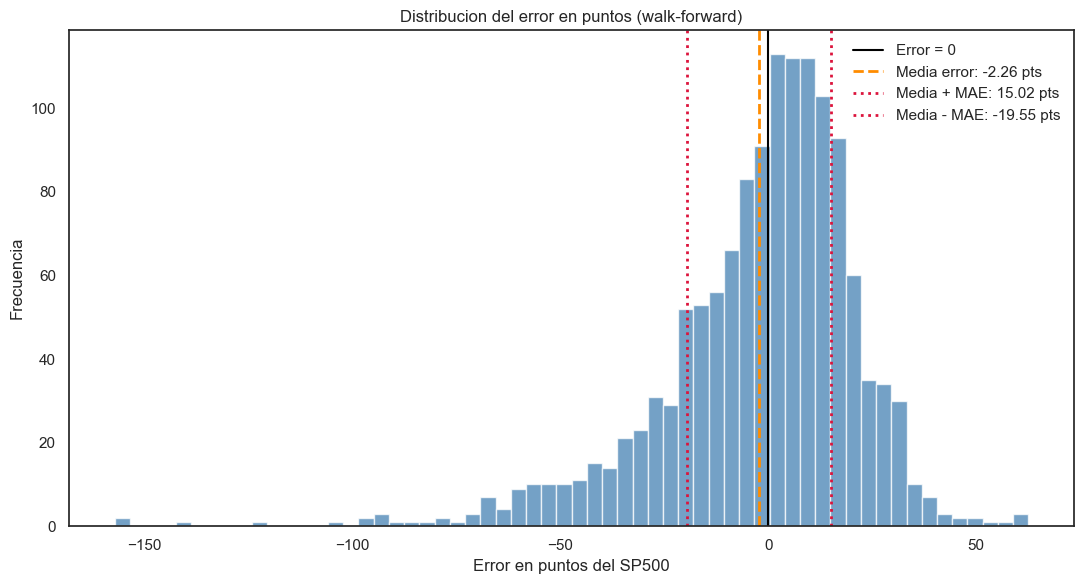

Rango predicho promedio: 52.99 puntos
Error promedio: -2.26 puntos
Error MAE: 17.29 puntos
Interpretacion: rango esperado ~ 52.99 ± 17.29 puntos


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

if "wf_preds" not in globals():
    raise ValueError("No existe wf_preds. Ejecuta la celda de walk-forward antes.")

err_log = wf_preds["y_pred"] - wf_preds["y_true"]
err_pct = np.exp(err_log) - 1

# Usa el precio de hoy si esta disponible para convertir el error a puntos
if "price_ref" in globals():
    price_ref_today = float(price_ref)
elif "close_today" in globals():
    price_ref_today = float(close_today)
elif "df" in globals() and "close" in df.columns:
    price_ref_today = float(df["close"].iloc[-1])
else:
    raise ValueError("No se encontro un precio base (price_ref/close_today/df['close']).")

err_points = err_pct * price_ref_today
mean_err_points = float(err_points.mean())
mae_points = float(np.mean(np.abs(err_points)))

pred_points_today = None
if "pred_points" in globals():
    pred_points_today = float(pred_points)
elif "pred_log" in globals():
    pred_points_today = float(price_ref_today * (np.exp(pred_log) - 1))

# Si hay prediccion del dia, mostrar distribucion del rango posible
if pred_points_today is not None:
    possible_range = pred_points_today + err_points
    plt.figure(figsize=(11, 6))
    plt.hist(possible_range, bins=60, color="steelblue", alpha=0.75, edgecolor="white")
    plt.axvline(pred_points_today, color="black", linestyle="-", linewidth=1.8, label=f"Pred: {pred_points_today:.2f} pts")
    plt.axvline(pred_points_today + mae_points, color="crimson", linestyle=":", linewidth=2, label=f"Pred + MAE: {pred_points_today + mae_points:.2f} pts")
    plt.axvline(pred_points_today - mae_points, color="crimson", linestyle=":", linewidth=2, label=f"Pred - MAE: {pred_points_today - mae_points:.2f} pts")

    plt.title("Distribucion del rango en puntos (pred ± error, precio de hoy)")
    plt.xlabel("Rango posible en puntos del SP500")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Prediccion rango puntos (hoy): {pred_points_today:.2f}")
    print(f"Error promedio: {mean_err_points:.2f} puntos")
    print(f"Error MAE (hoy): {mae_points:.2f} puntos")
    print(f"Rango esperado: {pred_points_today:.2f} ± {mae_points:.2f} puntos")
else:
    plt.figure(figsize=(11, 6))
    plt.hist(err_points, bins=60, color="steelblue", alpha=0.75, edgecolor="white")
    plt.axvline(0, color="black", linestyle="-", linewidth=1.5, label="Error = 0")
    plt.axvline(mean_err_points, color="darkorange", linestyle="--", linewidth=2, label=f"Media error: {mean_err_points:.2f} pts")
    plt.axvline(mean_err_points + mae_points, color="crimson", linestyle=":", linewidth=2, label=f"Media + MAE: {mean_err_points + mae_points:.2f} pts")
    plt.axvline(mean_err_points - mae_points, color="crimson", linestyle=":", linewidth=2, label=f"Media - MAE: {mean_err_points - mae_points:.2f} pts")

    plt.title("Distribucion del error en puntos (precio de hoy)")
    plt.xlabel("Error en puntos del SP500")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Error promedio: {mean_err_points:.2f} puntos")
    print(f"Error MAE (hoy): {mae_points:.2f} puntos")